# Damage Assessment Experiments - Ukrainian Cities finetuning

## Requirements

In [1]:
%%writefile requirements.txt
torch
torchvision
matplotlib
numpy
pandas
tqdm
opencv-python
albumentations

Writing requirements.txt


In [2]:
!pip install -r requirements.txt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 91.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 88.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 54.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 9.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 42.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitlin

## Imports

In [8]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

import sys
sys.path.append('/content/drive/MyDrive/thesis_code/classification')

import warnings
warnings.filterwarnings('ignore')

Mounted at /content/drive


In [6]:
import os
import pandas as pd
import torch
import cv2
import numpy as np
import matplotlib.pyplot as plt

from scripts.transforms import get_default_transforms
from scripts.k_folds import run_kfold_damagenet_experiments

## Data Retrieval

In [5]:
!unzip "/content/drive/MyDrive/thesis_code/classification/data/yakovlivka_data_equal.zip" -d "/content"
!unzip "/content/drive/MyDrive/thesis_code/classification/data/kamianka_data_equal.zip" -d "/content"
!unzip "/content/drive/MyDrive/thesis_code/classification/data/popasna_data_equal.zip" -d "/content"

Показано результат, скорочений до останніх рядків (5000).
  inflating: /content/yakovlivka_data/fold_0/mask/yakovlivka_61_662.png  
  inflating: /content/yakovlivka_data/fold_0/mask/yakovlivka_40_355.png  
  inflating: /content/yakovlivka_data/fold_0/mask/yakovlivka_45_395.png  
  inflating: /content/yakovlivka_data/fold_0/mask/yakovlivka_47_469.png  
  inflating: /content/yakovlivka_data/fold_0/mask/yakovlivka_32_103.png  
  inflating: /content/yakovlivka_data/fold_0/mask/yakovlivka_54_600.png  
  inflating: /content/yakovlivka_data/fold_0/mask/yakovlivka_52_524.png  
  inflating: /content/yakovlivka_data/fold_0/mask/yakovlivka_25_35.png  
  inflating: /content/yakovlivka_data/fold_0/mask/yakovlivka_54_568.png  
  inflating: /content/yakovlivka_data/fold_0/mask/yakovlivka_54_588.png  
  inflating: /content/yakovlivka_data/fold_0/mask/yakovlivka_24_21.png  
  inflating: /content/yakovlivka_data/fold_0/mask/yakovlivka_55_629.png  
  inflating: /content/yakovlivka_data/fold_0/mask/yakovl

## Experiments

### Yakovlivka


=== Fold 1 | Test folds: [0, 1] ===
['fold_0', 'fold_1']
['fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_6', 'fold_7', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 5/5 [00:00<00:00,  6.25it/s]


Train Loss: 1.1278, Precision: 0.5395, Recall: 0.5197, F1: 0.5253, Accuracy: 0.5197
Val Loss: 1.2867, Precision: 0.5229, Recall: 0.4276, F1: 0.4342, Accuracy: 0.4276

Epoch 2/30


...

Train Loss: 0.4555, Precision: 0.8342, Recall: 0.8339, F1: 0.8309, Accuracy: 0.8339
Val Loss: 0.9134, Precision: 0.5853, Recall: 0.5921, F1: 0.5772, Accuracy: 0.5921

Epoch 30/30


Validation: 100%|██████████| 5/5 [00:00<00:00,  6.03it/s]


Train Loss: 0.4221, Precision: 0.8459, Recall: 0.8454, F1: 0.8427, Accuracy: 0.8454
Val Loss: 0.9166, Precision: 0.5945, Recall: 0.5987, F1: 0.5879, Accuracy: 0.5987
Evaluating...


Evaluating DamageNet: 100%|██████████| 5/5 [00:00<00:00,  6.36it/s]



DamageNet Evaluation (Classification):
  Loss:      0.9166
  Accuracy:  0.5987
  Precision: 0.5945
  Recall:    0.5987
  F1 Score:  0.5879
  MSE:       0.6908
  MAE:       0.4934


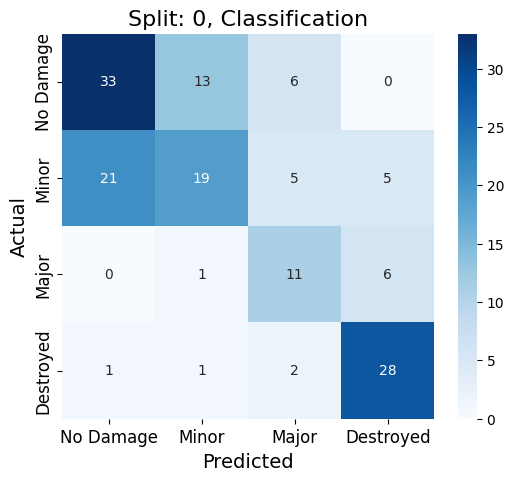


=== Fold 2 | Test folds: [2, 3] ===
['fold_2', 'fold_3']
['fold_0', 'fold_1', 'fold_4', 'fold_5', 'fold_6', 'fold_7', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 5/5 [00:00<00:00,  6.39it/s]


Train Loss: 1.1245, Precision: 0.5163, Recall: 0.5066, F1: 0.5088, Accuracy: 0.5066
Val Loss: 1.4477, Precision: 0.3891, Recall: 0.3882, F1: 0.3376, Accuracy: 0.3882

Epoch 2/30


...

Train Loss: 0.4486, Precision: 0.8377, Recall: 0.8355, F1: 0.8329, Accuracy: 0.8355
Val Loss: 1.0617, Precision: 0.5664, Recall: 0.5724, F1: 0.5578, Accuracy: 0.5724

Epoch 30/30


Validation: 100%|██████████| 5/5 [00:00<00:00,  6.15it/s]


Train Loss: 0.4175, Precision: 0.8630, Recall: 0.8635, F1: 0.8611, Accuracy: 0.8635
Val Loss: 1.1039, Precision: 0.5706, Recall: 0.5724, F1: 0.5552, Accuracy: 0.5724
Evaluating...


Evaluating DamageNet: 100%|██████████| 5/5 [00:00<00:00,  5.92it/s]



DamageNet Evaluation (Classification):
  Loss:      1.1039
  Accuracy:  0.5724
  Precision: 0.5706
  Recall:    0.5724
  F1 Score:  0.5552
  MSE:       1.0329
  MAE:       0.5987


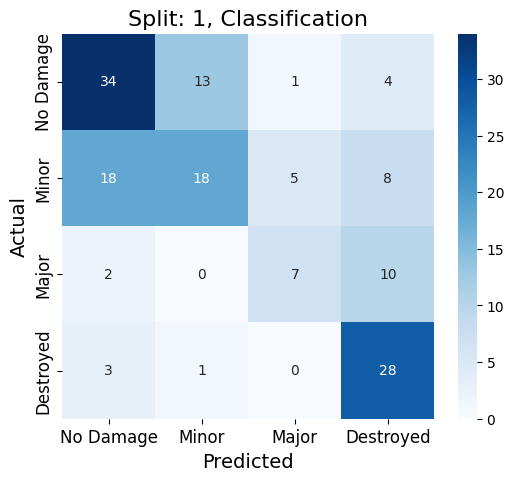


=== Fold 3 | Test folds: [4, 5] ===
['fold_4', 'fold_5']
['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_6', 'fold_7', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 5/5 [00:01<00:00,  4.26it/s]


Train Loss: 1.1269, Precision: 0.5137, Recall: 0.5000, F1: 0.5040, Accuracy: 0.5000
Val Loss: 1.4490, Precision: 0.4347, Recall: 0.3355, F1: 0.3485, Accuracy: 0.3355

Epoch 2/30


...

Train Loss: 0.4428, Precision: 0.8540, Recall: 0.8520, F1: 0.8481, Accuracy: 0.8520
Val Loss: 0.9957, Precision: 0.5631, Recall: 0.5855, F1: 0.5694, Accuracy: 0.5855

Epoch 30/30


Validation: 100%|██████████| 5/5 [00:00<00:00,  6.17it/s]


Train Loss: 0.4368, Precision: 0.8442, Recall: 0.8438, F1: 0.8424, Accuracy: 0.8438
Val Loss: 1.0167, Precision: 0.5669, Recall: 0.5855, F1: 0.5710, Accuracy: 0.5855
Evaluating...


Evaluating DamageNet: 100%|██████████| 5/5 [00:00<00:00,  6.37it/s]



DamageNet Evaluation (Classification):
  Loss:      1.0167
  Accuracy:  0.5855
  Precision: 0.5669
  Recall:    0.5855
  F1 Score:  0.5710
  MSE:       0.7171
  MAE:       0.5066


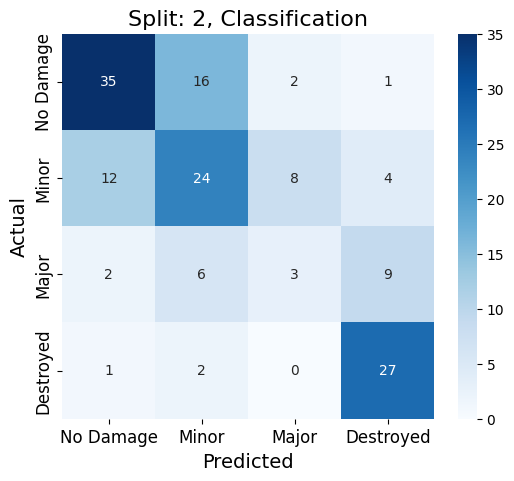


=== Fold 4 | Test folds: [6, 7] ===
['fold_6', 'fold_7']
['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 5/5 [00:00<00:00,  6.24it/s]


Train Loss: 1.1070, Precision: 0.5424, Recall: 0.5280, F1: 0.5318, Accuracy: 0.5280
Val Loss: 1.3761, Precision: 0.4145, Recall: 0.3421, F1: 0.3277, Accuracy: 0.3421

Epoch 2/30


...

Train Loss: 0.4447, Precision: 0.8469, Recall: 0.8438, F1: 0.8433, Accuracy: 0.8438
Val Loss: 1.0415, Precision: 0.5482, Recall: 0.5263, F1: 0.5109, Accuracy: 0.5263

Epoch 30/30


Validation: 100%|██████████| 5/5 [00:00<00:00,  5.09it/s]


Train Loss: 0.3978, Precision: 0.8616, Recall: 0.8602, F1: 0.8586, Accuracy: 0.8602
Val Loss: 1.0053, Precision: 0.5567, Recall: 0.5461, F1: 0.5269, Accuracy: 0.5461
Evaluating...


Evaluating DamageNet: 100%|██████████| 5/5 [00:00<00:00,  6.02it/s]



DamageNet Evaluation (Classification):
  Loss:      1.0053
  Accuracy:  0.5461
  Precision: 0.5567
  Recall:    0.5461
  F1 Score:  0.5269
  MSE:       0.8750
  MAE:       0.5855


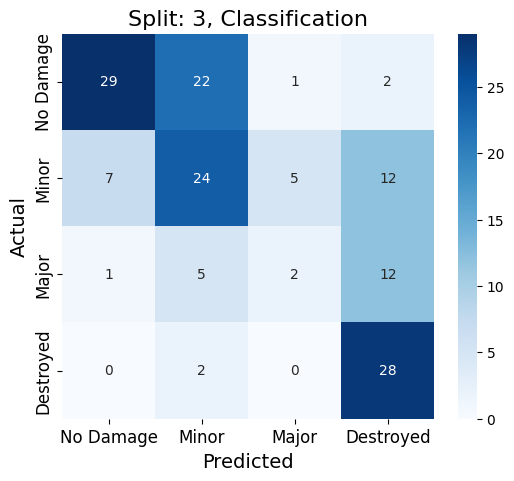


=== Fold 5 | Test folds: [8, 9] ===
['fold_8', 'fold_9']
['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_6', 'fold_7']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 5/5 [00:00<00:00,  6.33it/s]


Train Loss: 1.1412, Precision: 0.5333, Recall: 0.5115, F1: 0.5171, Accuracy: 0.5115
Val Loss: 1.2420, Precision: 0.4590, Recall: 0.4474, F1: 0.4299, Accuracy: 0.4474

Epoch 2/30


...

Train Loss: 0.4579, Precision: 0.8460, Recall: 0.8405, F1: 0.8375, Accuracy: 0.8405
Val Loss: 0.8958, Precision: 0.5923, Recall: 0.5789, F1: 0.5660, Accuracy: 0.5789

Epoch 30/30


Validation: 100%|██████████| 5/5 [00:01<00:00,  4.33it/s]


Train Loss: 0.4420, Precision: 0.8496, Recall: 0.8487, F1: 0.8469, Accuracy: 0.8487
Val Loss: 0.8874, Precision: 0.5886, Recall: 0.5789, F1: 0.5653, Accuracy: 0.5789
Evaluating...


Evaluating DamageNet: 100%|██████████| 5/5 [00:01<00:00,  4.04it/s]



DamageNet Evaluation (Classification):
  Loss:      0.8874
  Accuracy:  0.5789
  Precision: 0.5886
  Recall:    0.5789
  F1 Score:  0.5653
  MSE:       0.9211
  MAE:       0.5789


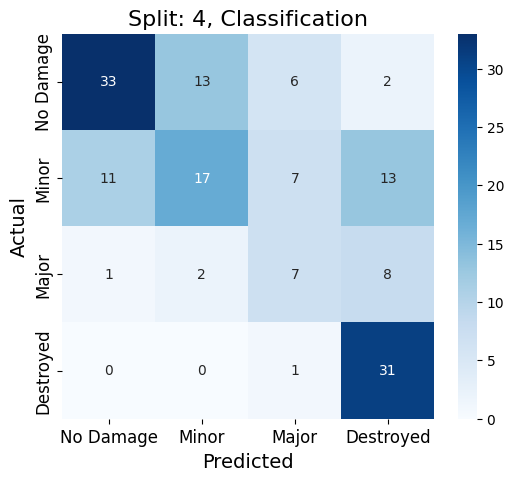


=== All Fold Test Metrics ===
       loss  accuracy  precision    recall  f1_score       mse       mae  \
0  0.916639  0.598684   0.594510  0.598684  0.587907  0.690789  0.493421   
1  1.103938  0.572368   0.570597  0.572368  0.555160  1.032895  0.598684   
2  1.016682  0.585526   0.566918  0.585526  0.571049  0.717105  0.506579   
3  1.005307  0.546053   0.556682  0.546053  0.526886  0.875000  0.585526   
4  0.887362  0.578947   0.588621  0.578947  0.565338  0.921053  0.578947   

   fold test_folds  
0     0     [0, 1]  
1     1     [2, 3]  
2     2     [4, 5]  
3     3     [6, 7]  
4     4     [8, 9]  


In [ ]:
yakovlivka_df_class = run_kfold_damagenet_experiments(
    DATA_DIR="/content/yakovlivka_data/",
    transform=get_default_transforms(),
    checkpoint_path="/content/drive/MyDrive/thesis_code/classification/models/model_DamageNet_10.pt",
    test_fold_combinations=[[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]],
    epochs=30
)

In [ ]:
output_path = '/content/drive/MyDrive/thesis_code/classification/results/df_yakovlivka_class.csv'
yakovlivka_df_class.to_csv(output_path, index=False)
print(f"\nSaved results to: {output_path}")


Saved results to: /content/drive/MyDrive/thesis_code/classification/results/df_yakovlivka_class.csv



=== Fold 1 | Test folds: [0, 1] ===
['fold_0', 'fold_1']
['fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_6', 'fold_7', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 5/5 [00:01<00:00,  4.13it/s]


Train Loss: 0.7098, Precision: 0.5824, Recall: 0.4474, F1: 0.4346, Accuracy: 0.4474
Val Loss: 0.9567, Precision: 0.4413, Recall: 0.3882, F1: 0.3343, Accuracy: 0.3882

Epoch 2/30


...

Train Loss: 0.1573, Precision: 0.8019, Recall: 0.7961, F1: 0.7973, Accuracy: 0.7961
Val Loss: 0.6823, Precision: 0.5326, Recall: 0.4868, F1: 0.4895, Accuracy: 0.4868

Epoch 30/30


Validation: 100%|██████████| 5/5 [00:00<00:00,  5.99it/s]


Train Loss: 0.1449, Precision: 0.8173, Recall: 0.8125, F1: 0.8142, Accuracy: 0.8125
Val Loss: 0.6889, Precision: 0.5267, Recall: 0.4803, F1: 0.4792, Accuracy: 0.4803
Evaluating...


Evaluating DamageNet: 100%|██████████| 5/5 [00:00<00:00,  5.77it/s]



DamageNet Evaluation (Regression):
  Loss:      0.6889
  Accuracy:  0.4803
  Precision: 0.5267
  Recall:    0.4803
  F1 Score:  0.4792
  MSE:       0.6982
  MAE:       0.6513


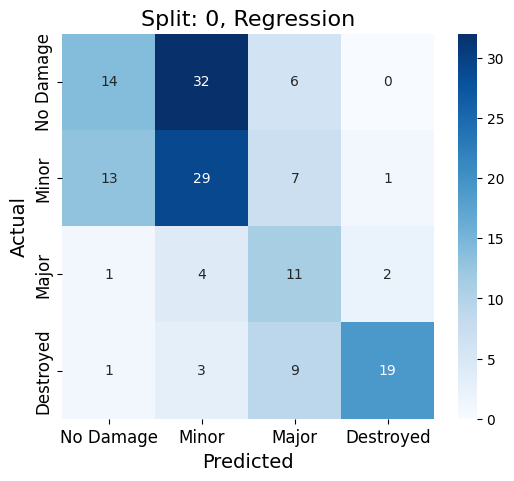


=== Fold 2 | Test folds: [2, 3] ===
['fold_2', 'fold_3']
['fold_0', 'fold_1', 'fold_4', 'fold_5', 'fold_6', 'fold_7', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 5/5 [00:01<00:00,  3.83it/s]


Train Loss: 0.7310, Precision: 0.5602, Recall: 0.4408, F1: 0.4181, Accuracy: 0.4408
Val Loss: 0.9774, Precision: 0.4891, Recall: 0.3684, F1: 0.3192, Accuracy: 0.3684

Epoch 2/30


...

Train Loss: 0.1550, Precision: 0.8109, Recall: 0.8076, F1: 0.8086, Accuracy: 0.8076
Val Loss: 0.7968, Precision: 0.5507, Recall: 0.4605, F1: 0.4495, Accuracy: 0.4605

Epoch 30/30


Validation: 100%|██████████| 5/5 [00:00<00:00,  5.88it/s]


Train Loss: 0.1430, Precision: 0.8166, Recall: 0.8125, F1: 0.8140, Accuracy: 0.8125
Val Loss: 0.7705, Precision: 0.5747, Recall: 0.4803, F1: 0.4800, Accuracy: 0.4803
Evaluating...


Evaluating DamageNet: 100%|██████████| 5/5 [00:00<00:00,  5.57it/s]



DamageNet Evaluation (Regression):
  Loss:      0.7705
  Accuracy:  0.4803
  Precision: 0.5747
  Recall:    0.4803
  F1 Score:  0.4800
  MSE:       0.7755
  MAE:       0.6764


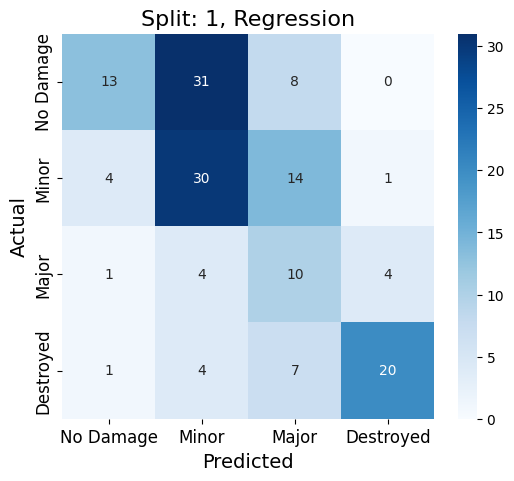


=== Fold 3 | Test folds: [4, 5] ===
['fold_4', 'fold_5']
['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_6', 'fold_7', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 5/5 [00:01<00:00,  4.00it/s]


Train Loss: 0.7797, Precision: 0.5374, Recall: 0.4178, F1: 0.3904, Accuracy: 0.4178
Val Loss: 0.8962, Precision: 0.6110, Recall: 0.4013, F1: 0.3671, Accuracy: 0.4013

Epoch 2/30


...

Train Loss: 0.1442, Precision: 0.8306, Recall: 0.8273, F1: 0.8286, Accuracy: 0.8273
Val Loss: 0.5451, Precision: 0.5865, Recall: 0.4605, F1: 0.4549, Accuracy: 0.4605

Epoch 30/30


Validation: 100%|██████████| 5/5 [00:00<00:00,  6.03it/s]


Train Loss: 0.1500, Precision: 0.8093, Recall: 0.8059, F1: 0.8072, Accuracy: 0.8059
Val Loss: 0.5547, Precision: 0.5780, Recall: 0.4474, F1: 0.4388, Accuracy: 0.4474
Evaluating...


Evaluating DamageNet: 100%|██████████| 5/5 [00:00<00:00,  6.16it/s]



DamageNet Evaluation (Regression):
  Loss:      0.5547
  Accuracy:  0.4474
  Precision: 0.5780
  Recall:    0.4474
  F1 Score:  0.4388
  MSE:       0.5494
  MAE:       0.5863


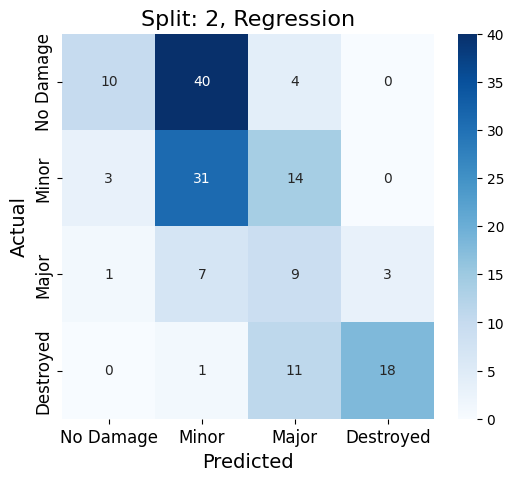


=== Fold 4 | Test folds: [6, 7] ===
['fold_6', 'fold_7']
['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 5/5 [00:00<00:00,  5.64it/s]


Train Loss: 0.7447, Precision: 0.5366, Recall: 0.4260, F1: 0.3976, Accuracy: 0.4260
Val Loss: 0.8998, Precision: 0.4838, Recall: 0.4079, F1: 0.3565, Accuracy: 0.4079

Epoch 2/30


...

Train Loss: 0.1413, Precision: 0.8097, Recall: 0.8076, F1: 0.8082, Accuracy: 0.8076
Val Loss: 0.7269, Precision: 0.6032, Recall: 0.5000, F1: 0.4905, Accuracy: 0.5000

Epoch 30/30


Validation: 100%|██████████| 5/5 [00:00<00:00,  5.84it/s]


Train Loss: 0.1454, Precision: 0.8229, Recall: 0.8158, F1: 0.8174, Accuracy: 0.8158
Val Loss: 0.7862, Precision: 0.5938, Recall: 0.4803, F1: 0.4638, Accuracy: 0.4803
Evaluating...


Evaluating DamageNet: 100%|██████████| 5/5 [00:00<00:00,  6.00it/s]



DamageNet Evaluation (Regression):
  Loss:      0.7862
  Accuracy:  0.4803
  Precision: 0.5938
  Recall:    0.4803
  F1 Score:  0.4638
  MSE:       0.7877
  MAE:       0.6893


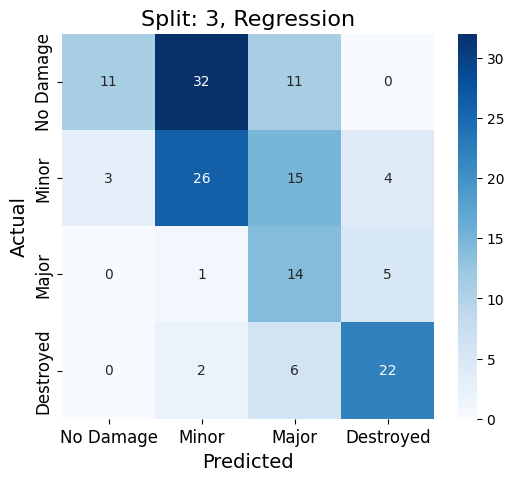


=== Fold 5 | Test folds: [8, 9] ===
['fold_8', 'fold_9']
['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_6', 'fold_7']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 5/5 [00:00<00:00,  5.25it/s]


Train Loss: 0.7452, Precision: 0.5532, Recall: 0.4227, F1: 0.3971, Accuracy: 0.4227
Val Loss: 0.8158, Precision: 0.5583, Recall: 0.3553, F1: 0.3364, Accuracy: 0.3553

Epoch 2/30


...

Train Loss: 0.1582, Precision: 0.7994, Recall: 0.7911, F1: 0.7934, Accuracy: 0.7911
Val Loss: 0.5384, Precision: 0.6594, Recall: 0.5066, F1: 0.5037, Accuracy: 0.5066

Epoch 30/30


Validation: 100%|██████████| 5/5 [00:00<00:00,  6.11it/s]


Train Loss: 0.1485, Precision: 0.8217, Recall: 0.8191, F1: 0.8198, Accuracy: 0.8191
Val Loss: 0.5041, Precision: 0.6706, Recall: 0.5197, F1: 0.5181, Accuracy: 0.5197
Evaluating...


Evaluating DamageNet: 100%|██████████| 5/5 [00:00<00:00,  5.88it/s]



DamageNet Evaluation (Regression):
  Loss:      0.5041
  Accuracy:  0.5197
  Precision: 0.6706
  Recall:    0.5197
  F1 Score:  0.5181
  MSE:       0.5115
  MAE:       0.5647


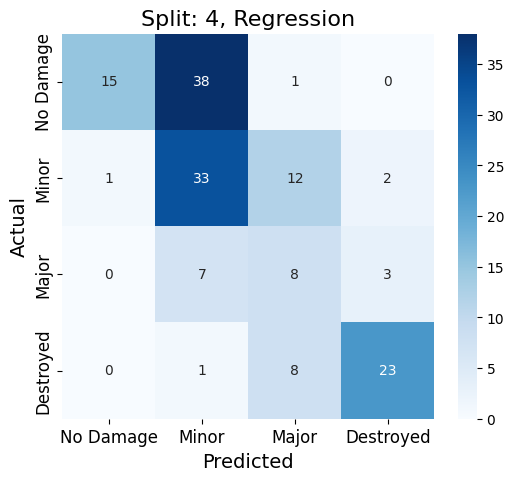


=== All Fold Test Metrics ===
       loss  accuracy  precision    recall  f1_score       mse       mae  \
0  0.688853  0.480263   0.526733  0.480263  0.479176  0.698249  0.651331   
1  0.770456  0.480263   0.574705  0.480263  0.480035  0.775516  0.676398   
2  0.554658  0.447368   0.578013  0.447368  0.438808  0.549437  0.586344   
3  0.786193  0.480263   0.593848  0.480263  0.463775  0.787697  0.689254   
4  0.504084  0.519737   0.670571  0.519737  0.518084  0.511468  0.564741   

   fold test_folds  
0     0     [0, 1]  
1     1     [2, 3]  
2     2     [4, 5]  
3     3     [6, 7]  
4     4     [8, 9]  


In [ ]:
yakovlivka_df_reg = run_kfold_damagenet_experiments(
    DATA_DIR="/content/yakovlivka_data/",
    transform=get_default_transforms(),
    checkpoint_path="/content/drive/MyDrive/thesis_code/classification/models/model_DamageNet_regression_15.pt",
    test_fold_combinations=[[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]],
    epochs=30,
    mode="regression"
)

In [ ]:
output_path = '/content/drive/MyDrive/thesis_code/classification/results/df_yakovlivka_reg.csv'
yakovlivka_df_reg.to_csv(output_path, index=False)
print(f"\nSaved results to: {output_path}")


Saved results to: /content/drive/MyDrive/thesis_code/classification/results/df_yakovlivka_reg.csv


### Kamianka


=== Fold 1 | Test folds: [0, 1] ===
['fold_0', 'fold_1']
['fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_6', 'fold_7', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 6/6 [00:00<00:00,  6.21it/s]


Train Loss: 1.3757, Precision: 0.4775, Recall: 0.4114, F1: 0.4177, Accuracy: 0.4114
Val Loss: 1.3983, Precision: 0.4140, Recall: 0.4128, F1: 0.4091, Accuracy: 0.4128

Epoch 2/30


...

Train Loss: 0.4707, Precision: 0.8175, Recall: 0.8170, F1: 0.8060, Accuracy: 0.8170
Val Loss: 1.2278, Precision: 0.5233, Recall: 0.5698, F1: 0.5074, Accuracy: 0.5698

Epoch 30/30


Validation: 100%|██████████| 6/6 [00:01<00:00,  5.64it/s]


Train Loss: 0.4481, Precision: 0.8393, Recall: 0.8389, F1: 0.8285, Accuracy: 0.8389
Val Loss: 1.1942, Precision: 0.5401, Recall: 0.5814, F1: 0.5243, Accuracy: 0.5814
Evaluating...


Evaluating DamageNet: 100%|██████████| 6/6 [00:00<00:00,  6.92it/s]



DamageNet Evaluation (Classification):
  Loss:      1.1942
  Accuracy:  0.5814
  Precision: 0.5401
  Recall:    0.5814
  F1 Score:  0.5243
  MSE:       0.9302
  MAE:       0.5814


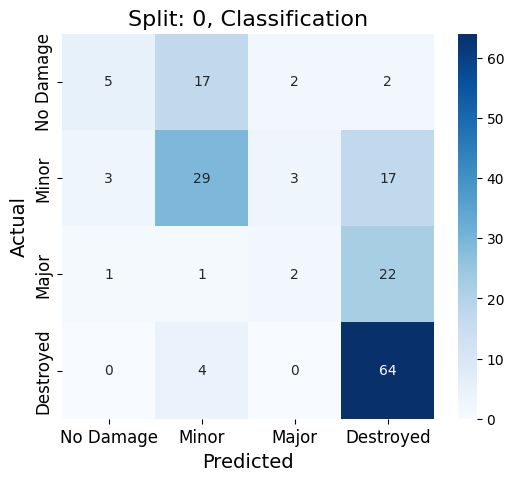


=== Fold 2 | Test folds: [2, 3] ===
['fold_2', 'fold_3']
['fold_0', 'fold_1', 'fold_4', 'fold_5', 'fold_6', 'fold_7', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 6/6 [00:00<00:00,  7.10it/s]


Train Loss: 1.4086, Precision: 0.4734, Recall: 0.4114, F1: 0.4174, Accuracy: 0.4114
Val Loss: 1.3750, Precision: 0.4692, Recall: 0.4360, F1: 0.4343, Accuracy: 0.4360

Epoch 2/30


...

Train Loss: 0.4953, Precision: 0.8156, Recall: 0.8141, F1: 0.8053, Accuracy: 0.8141
Val Loss: 1.0543, Precision: 0.5672, Recall: 0.5988, F1: 0.5654, Accuracy: 0.5988

Epoch 30/30


Validation: 100%|██████████| 6/6 [00:00<00:00,  7.21it/s]


Train Loss: 0.4624, Precision: 0.8379, Recall: 0.8375, F1: 0.8318, Accuracy: 0.8375
Val Loss: 1.0497, Precision: 0.5970, Recall: 0.6221, F1: 0.5883, Accuracy: 0.6221
Evaluating...


Evaluating DamageNet: 100%|██████████| 6/6 [00:00<00:00,  7.24it/s]



DamageNet Evaluation (Classification):
  Loss:      1.0497
  Accuracy:  0.6221
  Precision: 0.5970
  Recall:    0.6221
  F1 Score:  0.5883
  MSE:       1.0930
  MAE:       0.5814


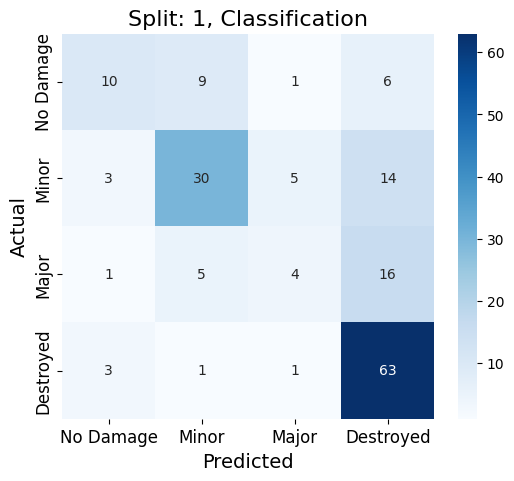


=== Fold 3 | Test folds: [4, 5] ===
['fold_4', 'fold_5']
['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_6', 'fold_7', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 6/6 [00:01<00:00,  4.78it/s]


Train Loss: 1.4260, Precision: 0.4867, Recall: 0.4108, F1: 0.4203, Accuracy: 0.4108
Val Loss: 1.2101, Precision: 0.4615, Recall: 0.4620, F1: 0.4535, Accuracy: 0.4620

Epoch 2/30


...

Train Loss: 0.4760, Precision: 0.8041, Recall: 0.8056, F1: 0.7928, Accuracy: 0.8056
Val Loss: 0.9715, Precision: 0.6009, Recall: 0.5965, F1: 0.5671, Accuracy: 0.5965

Epoch 30/30


Validation: 100%|██████████| 6/6 [00:00<00:00,  6.55it/s]


Train Loss: 0.4562, Precision: 0.8370, Recall: 0.8363, F1: 0.8279, Accuracy: 0.8363
Val Loss: 0.9770, Precision: 0.5900, Recall: 0.5906, F1: 0.5639, Accuracy: 0.5906
Evaluating...


Evaluating DamageNet: 100%|██████████| 6/6 [00:01<00:00,  4.73it/s]



DamageNet Evaluation (Classification):
  Loss:      0.9770
  Accuracy:  0.5906
  Precision: 0.5900
  Recall:    0.5906
  F1 Score:  0.5639
  MSE:       1.0468
  MAE:       0.6023


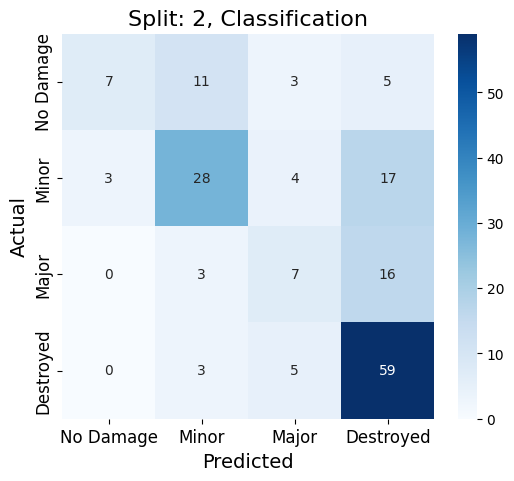


=== Fold 4 | Test folds: [6, 7] ===
['fold_6', 'fold_7']
['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 6/6 [00:00<00:00,  7.14it/s]


Train Loss: 1.4070, Precision: 0.4730, Recall: 0.4088, F1: 0.4183, Accuracy: 0.4088
Val Loss: 1.4054, Precision: 0.4285, Recall: 0.3941, F1: 0.3953, Accuracy: 0.3941

Epoch 2/30


...

Train Loss: 0.4936, Precision: 0.8248, Recall: 0.8263, F1: 0.8155, Accuracy: 0.8263
Val Loss: 1.1460, Precision: 0.6171, Recall: 0.6176, F1: 0.5884, Accuracy: 0.6176

Epoch 30/30


Validation: 100%|██████████| 6/6 [00:00<00:00,  7.08it/s]


Train Loss: 0.4618, Precision: 0.8218, Recall: 0.8234, F1: 0.8114, Accuracy: 0.8234
Val Loss: 1.1337, Precision: 0.6511, Recall: 0.6471, F1: 0.6242, Accuracy: 0.6471
Evaluating...


Evaluating DamageNet: 100%|██████████| 6/6 [00:00<00:00,  7.07it/s]



DamageNet Evaluation (Classification):
  Loss:      1.1337
  Accuracy:  0.6471
  Precision: 0.6511
  Recall:    0.6471
  F1 Score:  0.6242
  MSE:       0.8353
  MAE:       0.4941


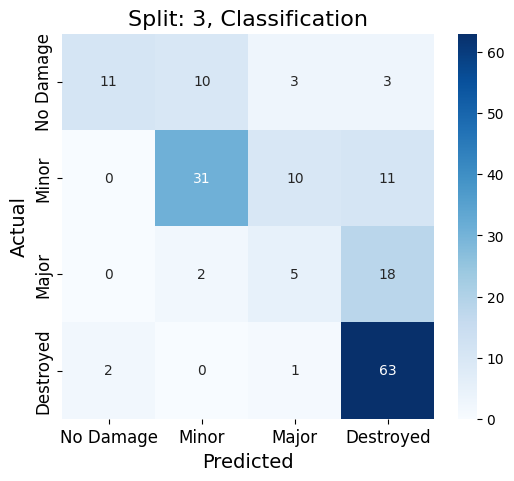


=== Fold 5 | Test folds: [8, 9] ===
['fold_8', 'fold_9']
['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_6', 'fold_7']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 6/6 [00:00<00:00,  6.98it/s]


Train Loss: 1.4114, Precision: 0.4719, Recall: 0.3985, F1: 0.4094, Accuracy: 0.3985
Val Loss: 1.3655, Precision: 0.5045, Recall: 0.4824, F1: 0.4814, Accuracy: 0.4824

Epoch 2/30


...

Train Loss: 0.4517, Precision: 0.8382, Recall: 0.8350, F1: 0.8264, Accuracy: 0.8350
Val Loss: 1.5345, Precision: 0.5149, Recall: 0.5118, F1: 0.4540, Accuracy: 0.5118

Epoch 30/30


Validation: 100%|██████████| 6/6 [00:00<00:00,  6.76it/s]


Train Loss: 0.4582, Precision: 0.8370, Recall: 0.8380, F1: 0.8308, Accuracy: 0.8380
Val Loss: 1.4916, Precision: 0.5231, Recall: 0.5176, F1: 0.4667, Accuracy: 0.5176
Evaluating...


Evaluating DamageNet: 100%|██████████| 6/6 [00:00<00:00,  6.96it/s]



DamageNet Evaluation (Classification):
  Loss:      1.4916
  Accuracy:  0.5176
  Precision: 0.5231
  Recall:    0.5176
  F1 Score:  0.4667
  MSE:       1.2000
  MAE:       0.7059


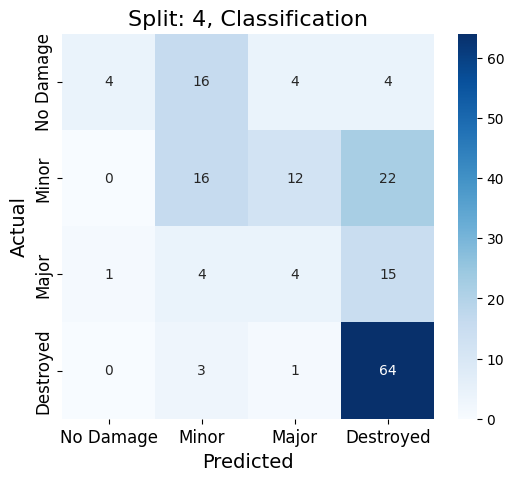


=== All Fold Test Metrics ===
       loss  accuracy  precision    recall  f1_score       mse       mae  \
0  1.194179  0.581395   0.540054  0.581395  0.524266  0.930233  0.581395   
1  1.049732  0.622093   0.597024  0.622093  0.588285  1.093023  0.581395   
2  0.976978  0.590643   0.589983  0.590643  0.563906  1.046784  0.602339   
3  1.133692  0.647059   0.651070  0.647059  0.624240  0.835294  0.494118   
4  1.491570  0.517647   0.523129  0.517647  0.466731  1.200000  0.705882   

   fold test_folds  
0     0     [0, 1]  
1     1     [2, 3]  
2     2     [4, 5]  
3     3     [6, 7]  
4     4     [8, 9]  


In [ ]:
kamianka_df_class = run_kfold_damagenet_experiments(
    DATA_DIR="/content/kamianka_data/",
    transform=get_default_transforms(),
    checkpoint_path="/content/drive/MyDrive/thesis_code/classification/models/model_DamageNet_10.pt",
    test_fold_combinations=[[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]],
    epochs=30
)

In [ ]:
output_path = '/content/drive/MyDrive/thesis_code/classification/results/df_kamianka_class.csv'
kamianka_df_class.to_csv(output_path, index=False)
print(f"\nSaved results to: {output_path}")


Saved results to: /content/drive/MyDrive/thesis_code/classification/results/df_kamianka_class.csv



=== Fold 1 | Test folds: [0, 1] ===
['fold_0', 'fold_1']
['fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_6', 'fold_7', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 6/6 [00:00<00:00,  7.20it/s]


Train Loss: 0.9843, Precision: 0.5464, Recall: 0.3777, F1: 0.3817, Accuracy: 0.3777
Val Loss: 0.8624, Precision: 0.4935, Recall: 0.4186, F1: 0.4324, Accuracy: 0.4186

Epoch 2/30


...

Train Loss: 0.1820, Precision: 0.7980, Recall: 0.7906, F1: 0.7918, Accuracy: 0.7906
Val Loss: 0.8285, Precision: 0.5620, Recall: 0.5465, F1: 0.5280, Accuracy: 0.5465

Epoch 30/30


Validation: 100%|██████████| 6/6 [00:00<00:00,  6.73it/s]


Train Loss: 0.1679, Precision: 0.8069, Recall: 0.7936, F1: 0.7972, Accuracy: 0.7936
Val Loss: 0.7557, Precision: 0.5944, Recall: 0.5756, F1: 0.5613, Accuracy: 0.5756
Evaluating...


Evaluating DamageNet: 100%|██████████| 6/6 [00:00<00:00,  6.72it/s]



DamageNet Evaluation (Regression):
  Loss:      0.7557
  Accuracy:  0.5756
  Precision: 0.5944
  Recall:    0.5756
  F1 Score:  0.5613
  MSE:       0.6700
  MAE:       0.5919


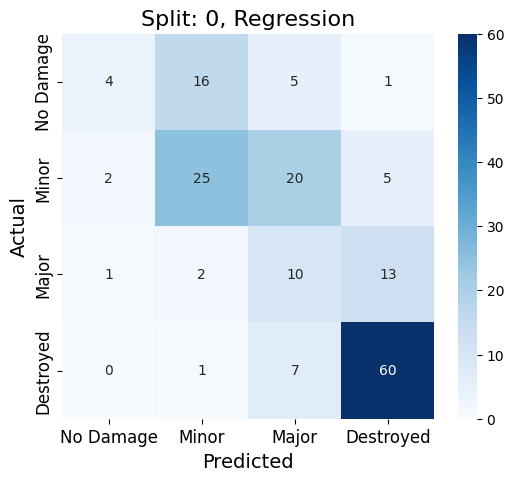


=== Fold 2 | Test folds: [2, 3] ===
['fold_2', 'fold_3']
['fold_0', 'fold_1', 'fold_4', 'fold_5', 'fold_6', 'fold_7', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 6/6 [00:02<00:00,  2.88it/s]


Train Loss: 1.0076, Precision: 0.5456, Recall: 0.3660, F1: 0.3662, Accuracy: 0.3660
Val Loss: 0.9242, Precision: 0.5282, Recall: 0.4302, F1: 0.4441, Accuracy: 0.4302

Epoch 2/30


...

Train Loss: 0.1798, Precision: 0.7963, Recall: 0.7833, F1: 0.7872, Accuracy: 0.7833
Val Loss: 0.9535, Precision: 0.5289, Recall: 0.5233, F1: 0.5054, Accuracy: 0.5233

Epoch 30/30


Validation: 100%|██████████| 6/6 [00:00<00:00,  7.05it/s]


Train Loss: 0.1805, Precision: 0.7877, Recall: 0.7701, F1: 0.7749, Accuracy: 0.7701
Val Loss: 0.9577, Precision: 0.5389, Recall: 0.5291, F1: 0.5127, Accuracy: 0.5291
Evaluating...


Evaluating DamageNet: 100%|██████████| 6/6 [00:00<00:00,  6.75it/s]



DamageNet Evaluation (Regression):
  Loss:      0.9577
  Accuracy:  0.5291
  Precision: 0.5389
  Recall:    0.5291
  F1 Score:  0.5127
  MSE:       0.8434
  MAE:       0.6750


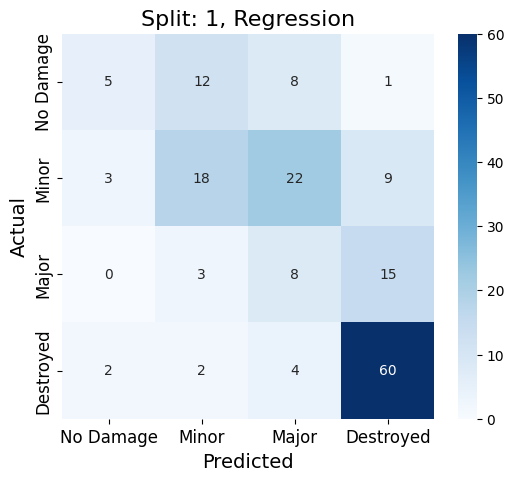


=== Fold 3 | Test folds: [4, 5] ===
['fold_4', 'fold_5']
['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_6', 'fold_7', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 6/6 [00:00<00:00,  6.72it/s]


Train Loss: 0.9849, Precision: 0.5484, Recall: 0.3947, F1: 0.3980, Accuracy: 0.3947
Val Loss: 0.7511, Precision: 0.5683, Recall: 0.4561, F1: 0.4674, Accuracy: 0.4561

Epoch 2/30


...

Train Loss: 0.1876, Precision: 0.8044, Recall: 0.7836, F1: 0.7876, Accuracy: 0.7836
Val Loss: 0.6496, Precision: 0.6157, Recall: 0.5556, F1: 0.5428, Accuracy: 0.5556

Epoch 30/30


Validation: 100%|██████████| 6/6 [00:00<00:00,  6.79it/s]


Train Loss: 0.1759, Precision: 0.8179, Recall: 0.7997, F1: 0.8041, Accuracy: 0.7997
Val Loss: 0.6473, Precision: 0.6332, Recall: 0.5789, F1: 0.5656, Accuracy: 0.5789
Evaluating...


Evaluating DamageNet: 100%|██████████| 6/6 [00:00<00:00,  6.86it/s]



DamageNet Evaluation (Regression):
  Loss:      0.6473
  Accuracy:  0.5789
  Precision: 0.6332
  Recall:    0.5789
  F1 Score:  0.5656
  MSE:       0.6693
  MAE:       0.5886


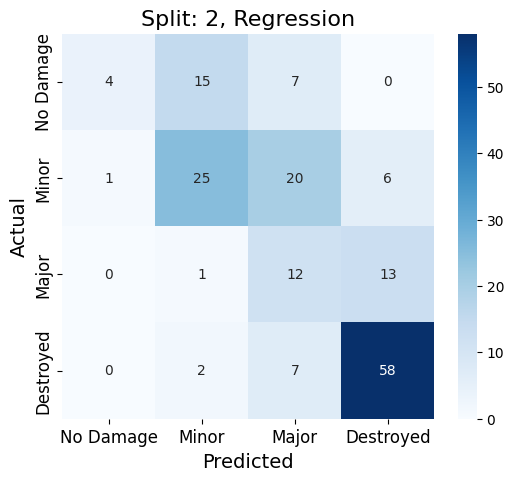


=== Fold 4 | Test folds: [6, 7] ===
['fold_6', 'fold_7']
['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 6/6 [00:00<00:00,  6.85it/s]


Train Loss: 0.9656, Precision: 0.5122, Recall: 0.3737, F1: 0.3759, Accuracy: 0.3737
Val Loss: 1.0364, Precision: 0.5175, Recall: 0.3824, F1: 0.3943, Accuracy: 0.3824

Epoch 2/30


...

Train Loss: 0.1949, Precision: 0.7958, Recall: 0.7796, F1: 0.7834, Accuracy: 0.7796
Val Loss: 0.9064, Precision: 0.4519, Recall: 0.5118, F1: 0.4710, Accuracy: 0.5118

Epoch 30/30


Validation: 100%|██████████| 6/6 [00:00<00:00,  6.60it/s]


Train Loss: 0.1627, Precision: 0.8196, Recall: 0.8102, F1: 0.8133, Accuracy: 0.8102
Val Loss: 0.8808, Precision: 0.6162, Recall: 0.5235, F1: 0.4896, Accuracy: 0.5235
Evaluating...


Evaluating DamageNet: 100%|██████████| 6/6 [00:00<00:00,  6.91it/s]



DamageNet Evaluation (Regression):
  Loss:      0.8808
  Accuracy:  0.5235
  Precision: 0.6162
  Recall:    0.5235
  F1 Score:  0.4896
  MSE:       0.8598
  MAE:       0.6789


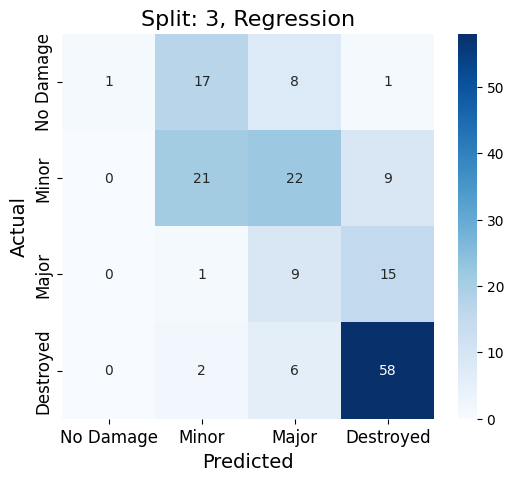


=== Fold 5 | Test folds: [8, 9] ===
['fold_8', 'fold_9']
['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_6', 'fold_7']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 6/6 [00:01<00:00,  4.68it/s]


Train Loss: 0.9397, Precision: 0.5414, Recall: 0.3796, F1: 0.3815, Accuracy: 0.3796
Val Loss: 1.0087, Precision: 0.5128, Recall: 0.3706, F1: 0.3953, Accuracy: 0.3706

Epoch 2/30


...

Train Loss: 0.1845, Precision: 0.7963, Recall: 0.7825, F1: 0.7855, Accuracy: 0.7825
Val Loss: 1.0995, Precision: 0.5372, Recall: 0.4529, F1: 0.4016, Accuracy: 0.4529

Epoch 30/30


Validation: 100%|██████████| 6/6 [00:01<00:00,  4.70it/s]


Train Loss: 0.1598, Precision: 0.8240, Recall: 0.8131, F1: 0.8149, Accuracy: 0.8131
Val Loss: 1.0978, Precision: 0.5370, Recall: 0.4647, F1: 0.4144, Accuracy: 0.4647
Evaluating...


Evaluating DamageNet: 100%|██████████| 6/6 [00:00<00:00,  6.68it/s]



DamageNet Evaluation (Regression):
  Loss:      1.0978
  Accuracy:  0.4647
  Precision: 0.5370
  Recall:    0.4647
  F1 Score:  0.4144
  MSE:       1.1273
  MAE:       0.8031


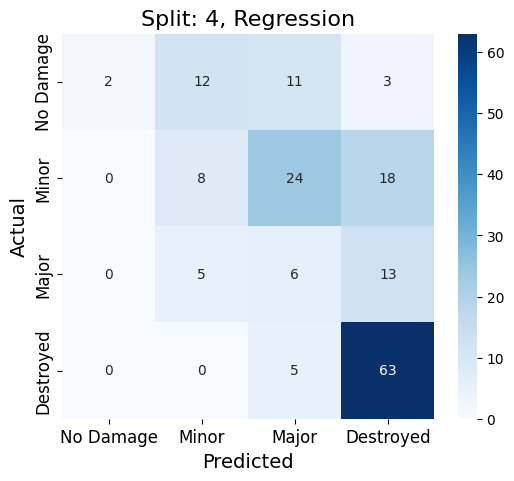


=== All Fold Test Metrics ===
       loss  accuracy  precision    recall  f1_score       mse       mae  \
0  0.755749  0.575581   0.594411  0.575581  0.561300  0.670032  0.591887   
1  0.957692  0.529070   0.538926  0.529070  0.512735  0.843430  0.675020   
2  0.647252  0.578947   0.633232  0.578947  0.565596  0.669317  0.588637   
3  0.880840  0.523529   0.616204  0.523529  0.489550  0.859841  0.678857   
4  1.097768  0.464706   0.537032  0.464706  0.414362  1.127264  0.803115   

   fold test_folds  
0     0     [0, 1]  
1     1     [2, 3]  
2     2     [4, 5]  
3     3     [6, 7]  
4     4     [8, 9]  


In [ ]:
kamianka_df_reg = run_kfold_damagenet_experiments(
    DATA_DIR="/content/kamianka_data/",
    transform=get_default_transforms(),
    checkpoint_path="/content/drive/MyDrive/thesis_code/classification/models/model_DamageNet_regression_15.pt",
    test_fold_combinations=[[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]],
    epochs=30,
    mode="regression"
)

In [ ]:
output_path = '/content/drive/MyDrive/thesis_code/classification/results/df_kamianka_reg.csv'
kamianka_df_reg.to_csv(output_path, index=False)
print(f"\nSaved results to: {output_path}")


Saved results to: /content/drive/MyDrive/thesis_code/classification/results/df_kamianka_reg.csv


### Popasna


=== Fold 1 | Test folds: [0, 1] ===
['fold_0', 'fold_1']
['fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_6', 'fold_7', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 4/4 [00:00<00:00,  5.63it/s]


Train Loss: 1.2234, Precision: 0.4767, Recall: 0.4398, F1: 0.4444, Accuracy: 0.4398
Val Loss: 1.3620, Precision: 0.4626, Recall: 0.5000, F1: 0.4580, Accuracy: 0.5000

Epoch 2/30


...

Train Loss: 0.4974, Precision: 0.8299, Recall: 0.8320, F1: 0.8264, Accuracy: 0.8320
Val Loss: 1.0894, Precision: 0.6167, Recall: 0.5902, F1: 0.5565, Accuracy: 0.5902

Epoch 30/30


Validation: 100%|██████████| 4/4 [00:00<00:00,  5.89it/s]


Train Loss: 0.5142, Precision: 0.8254, Recall: 0.8257, F1: 0.8222, Accuracy: 0.8257
Val Loss: 1.1649, Precision: 0.6217, Recall: 0.5820, F1: 0.5423, Accuracy: 0.5820
Evaluating...


Evaluating DamageNet: 100%|██████████| 4/4 [00:00<00:00,  5.89it/s]



DamageNet Evaluation (Classification):
  Loss:      1.1649
  Accuracy:  0.5820
  Precision: 0.6217
  Recall:    0.5820
  F1 Score:  0.5423
  MSE:       1.0410
  MAE:       0.5984


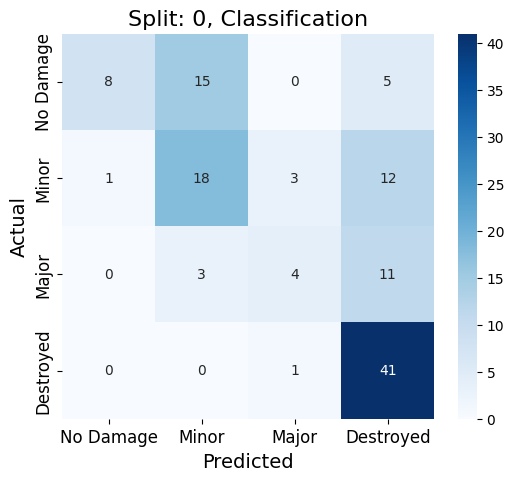


=== Fold 2 | Test folds: [2, 3] ===
['fold_2', 'fold_3']
['fold_0', 'fold_1', 'fold_4', 'fold_5', 'fold_6', 'fold_7', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 4/4 [00:00<00:00,  5.21it/s]


Train Loss: 1.2768, Precision: 0.5245, Recall: 0.4730, F1: 0.4824, Accuracy: 0.4730
Val Loss: 1.2196, Precision: 0.4508, Recall: 0.5000, F1: 0.4493, Accuracy: 0.5000

Epoch 2/30


...

Train Loss: 0.5717, Precision: 0.7927, Recall: 0.7925, F1: 0.7875, Accuracy: 0.7925
Val Loss: 1.0806, Precision: 0.5826, Recall: 0.5574, F1: 0.5011, Accuracy: 0.5574

Epoch 30/30


Validation: 100%|██████████| 4/4 [00:00<00:00,  5.33it/s]


Train Loss: 0.5659, Precision: 0.7917, Recall: 0.7925, F1: 0.7865, Accuracy: 0.7925
Val Loss: 1.0707, Precision: 0.5893, Recall: 0.5656, F1: 0.5089, Accuracy: 0.5656
Evaluating...


Evaluating DamageNet: 100%|██████████| 4/4 [00:00<00:00,  5.36it/s]



DamageNet Evaluation (Classification):
  Loss:      1.0707
  Accuracy:  0.5656
  Precision: 0.5893
  Recall:    0.5656
  F1 Score:  0.5089
  MSE:       0.8770
  MAE:       0.5656


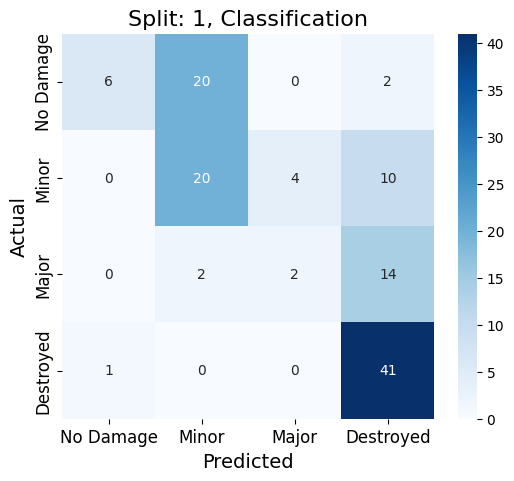


=== Fold 3 | Test folds: [4, 5] ===
['fold_4', 'fold_5']
['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_6', 'fold_7', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 4/4 [00:00<00:00,  5.50it/s]


Train Loss: 1.2245, Precision: 0.5045, Recall: 0.4544, F1: 0.4633, Accuracy: 0.4544
Val Loss: 1.2514, Precision: 0.4737, Recall: 0.5246, F1: 0.4717, Accuracy: 0.5246

Epoch 2/30


...

Train Loss: 0.5248, Precision: 0.8343, Recall: 0.8299, F1: 0.8268, Accuracy: 0.8299
Val Loss: 1.1354, Precision: 0.5998, Recall: 0.6066, F1: 0.5677, Accuracy: 0.6066

Epoch 30/30


Validation: 100%|██████████| 4/4 [00:00<00:00,  5.65it/s]


Train Loss: 0.5707, Precision: 0.8338, Recall: 0.8320, F1: 0.8309, Accuracy: 0.8320
Val Loss: 1.1375, Precision: 0.5624, Recall: 0.5902, F1: 0.5436, Accuracy: 0.5902
Evaluating...


Evaluating DamageNet: 100%|██████████| 4/4 [00:00<00:00,  5.40it/s]



DamageNet Evaluation (Classification):
  Loss:      1.1375
  Accuracy:  0.5902
  Precision: 0.5624
  Recall:    0.5902
  F1 Score:  0.5436
  MSE:       0.7869
  MAE:       0.5246


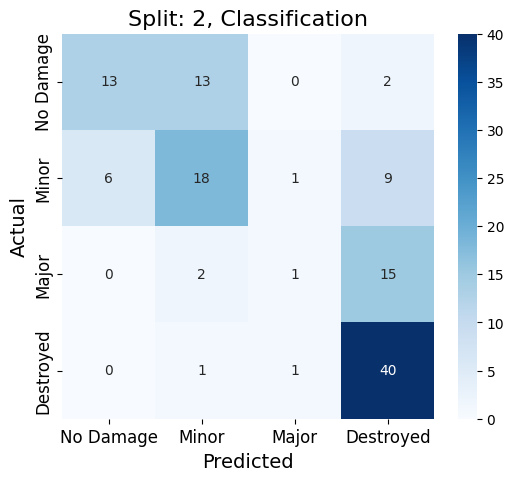


=== Fold 4 | Test folds: [6, 7] ===
['fold_6', 'fold_7']
['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 4/4 [00:00<00:00,  5.56it/s]


Train Loss: 1.3214, Precision: 0.5090, Recall: 0.4649, F1: 0.4717, Accuracy: 0.4649
Val Loss: 1.1601, Precision: 0.4766, Recall: 0.5167, F1: 0.4699, Accuracy: 0.5167

Epoch 2/30


...

Train Loss: 0.4853, Precision: 0.8474, Recall: 0.8450, F1: 0.8419, Accuracy: 0.8450
Val Loss: 1.0072, Precision: 0.5783, Recall: 0.5917, F1: 0.5611, Accuracy: 0.5917

Epoch 30/30


Validation: 100%|██████████| 4/4 [00:00<00:00,  5.41it/s]


Train Loss: 0.5136, Precision: 0.8356, Recall: 0.8347, F1: 0.8291, Accuracy: 0.8347
Val Loss: 1.0704, Precision: 0.5573, Recall: 0.5667, F1: 0.5286, Accuracy: 0.5667
Evaluating...


Evaluating DamageNet: 100%|██████████| 4/4 [00:01<00:00,  3.94it/s]



DamageNet Evaluation (Classification):
  Loss:      1.0704
  Accuracy:  0.5667
  Precision: 0.5573
  Recall:    0.5667
  F1 Score:  0.5286
  MSE:       0.7500
  MAE:       0.5333


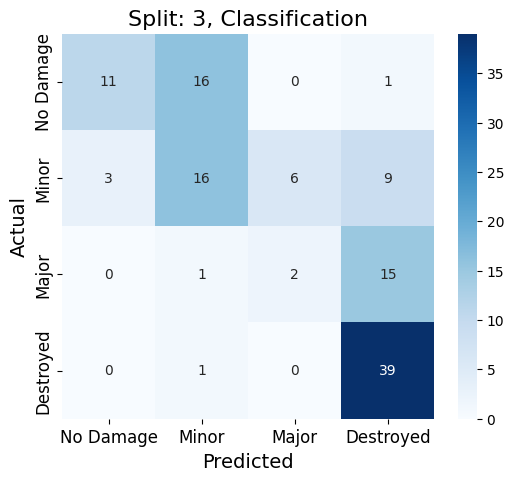


=== Fold 5 | Test folds: [8, 9] ===
['fold_8', 'fold_9']
['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_6', 'fold_7']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 4/4 [00:00<00:00,  5.22it/s]


Train Loss: 1.2495, Precision: 0.5010, Recall: 0.4568, F1: 0.4633, Accuracy: 0.4568
Val Loss: 1.2229, Precision: 0.4283, Recall: 0.4915, F1: 0.4446, Accuracy: 0.4915

Epoch 2/30


...

Train Loss: 0.5541, Precision: 0.8059, Recall: 0.8086, F1: 0.8048, Accuracy: 0.8086
Val Loss: 0.9140, Precision: 0.6291, Recall: 0.6271, F1: 0.6108, Accuracy: 0.6271

Epoch 30/30


Validation: 100%|██████████| 4/4 [00:01<00:00,  3.74it/s]


Train Loss: 0.4879, Precision: 0.8248, Recall: 0.8272, F1: 0.8220, Accuracy: 0.8272
Val Loss: 0.9561, Precision: 0.6358, Recall: 0.6271, F1: 0.6119, Accuracy: 0.6271
Evaluating...


Evaluating DamageNet: 100%|██████████| 4/4 [00:01<00:00,  3.57it/s]



DamageNet Evaluation (Classification):
  Loss:      0.9561
  Accuracy:  0.6271
  Precision: 0.6358
  Recall:    0.6271
  F1 Score:  0.6119
  MSE:       0.6949
  MAE:       0.4746


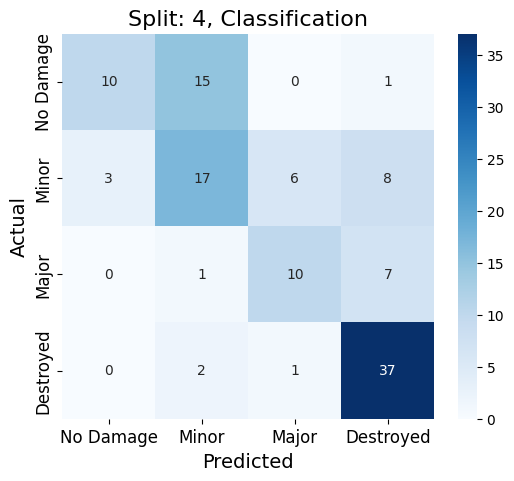


=== All Fold Test Metrics ===
       loss  accuracy  precision    recall  f1_score       mse       mae  \
0  1.164851  0.581967   0.621684  0.581967  0.542289  1.040984  0.598361   
1  1.070700  0.565574   0.589278  0.565574  0.508943  0.877049  0.565574   
2  1.137468  0.590164   0.562397  0.590164  0.543564  0.786885  0.524590   
3  1.070408  0.566667   0.557292  0.566667  0.528632  0.750000  0.533333   
4  0.956094  0.627119   0.635822  0.627119  0.611870  0.694915  0.474576   

   fold test_folds  
0     0     [0, 1]  
1     1     [2, 3]  
2     2     [4, 5]  
3     3     [6, 7]  
4     4     [8, 9]  


In [ ]:
popasna_df_class = run_kfold_damagenet_experiments(
    DATA_DIR="/content/popasna_data/",
    transform=get_default_transforms(),
    checkpoint_path="/content/drive/MyDrive/thesis_code/classification/models/model_DamageNet_10.pt",
    test_fold_combinations=[[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]],
    epochs=30
)

In [ ]:
output_path = '/content/drive/MyDrive/thesis_code/classification/results/df_popasna_class.csv'
popasna_df_class.to_csv(output_path, index=False)
print(f"\nSaved results to: {output_path}")


Saved results to: /content/drive/MyDrive/thesis_code/classification/results/df_popasna_class.csv



=== Fold 1 | Test folds: [0, 1] ===
['fold_0', 'fold_1']
['fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_6', 'fold_7', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 4/4 [00:01<00:00,  3.23it/s]


Train Loss: 0.8086, Precision: 0.5470, Recall: 0.3963, F1: 0.3853, Accuracy: 0.3963
Val Loss: 0.9673, Precision: 0.5249, Recall: 0.3852, F1: 0.3692, Accuracy: 0.3852

Epoch 2/30


...

Train Loss: 0.3305, Precision: 0.7838, Recall: 0.7718, F1: 0.7746, Accuracy: 0.7718
Val Loss: 1.0463, Precision: 0.4958, Recall: 0.4344, F1: 0.4019, Accuracy: 0.4344

Epoch 30/30


Validation: 100%|██████████| 4/4 [00:00<00:00,  5.39it/s]


Train Loss: 0.2046, Precision: 0.7870, Recall: 0.7697, F1: 0.7752, Accuracy: 0.7697
Val Loss: 0.8633, Precision: 0.5500, Recall: 0.4672, F1: 0.4544, Accuracy: 0.4672
Evaluating...


Evaluating DamageNet: 100%|██████████| 4/4 [00:00<00:00,  5.52it/s]



DamageNet Evaluation (Regression):
  Loss:      0.8633
  Accuracy:  0.4672
  Precision: 0.5500
  Recall:    0.4672
  F1 Score:  0.4544
  MSE:       0.8391
  MAE:       0.6825


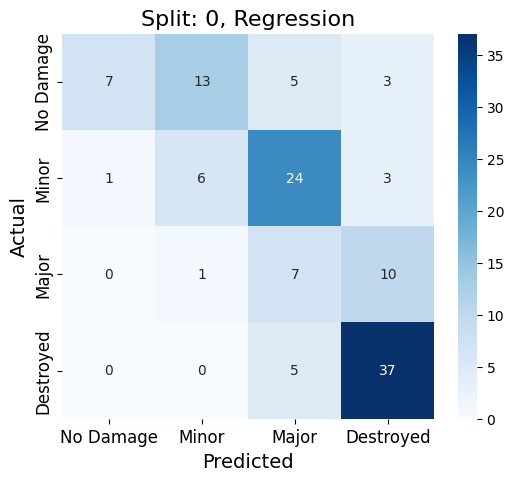


=== Fold 2 | Test folds: [2, 3] ===
['fold_2', 'fold_3']
['fold_0', 'fold_1', 'fold_4', 'fold_5', 'fold_6', 'fold_7', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 4/4 [00:00<00:00,  5.12it/s]
/usr/local/lib/python3.11/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


Train Loss: 0.7320, Precision: 0.5452, Recall: 0.3983, F1: 0.3961, Accuracy: 0.3983
Val Loss: 1.1009, Precision: 0.3303, Recall: 0.4098, F1: 0.3595, Accuracy: 0.4098

Epoch 2/30


...

Train Loss: 0.2204, Precision: 0.7969, Recall: 0.7842, F1: 0.7881, Accuracy: 0.7842
Val Loss: 0.8638, Precision: 0.6054, Recall: 0.5000, F1: 0.4811, Accuracy: 0.5000

Epoch 30/30


Validation: 100%|██████████| 4/4 [00:00<00:00,  4.98it/s]


Train Loss: 0.1787, Precision: 0.7915, Recall: 0.7759, F1: 0.7806, Accuracy: 0.7759
Val Loss: 1.0324, Precision: 0.5764, Recall: 0.4426, F1: 0.3967, Accuracy: 0.4426
Evaluating...


Evaluating DamageNet: 100%|██████████| 4/4 [00:00<00:00,  4.97it/s]



DamageNet Evaluation (Regression):
  Loss:      1.0324
  Accuracy:  0.4426
  Precision: 0.5764
  Recall:    0.4426
  F1 Score:  0.3967
  MSE:       0.9840
  MAE:       0.7692


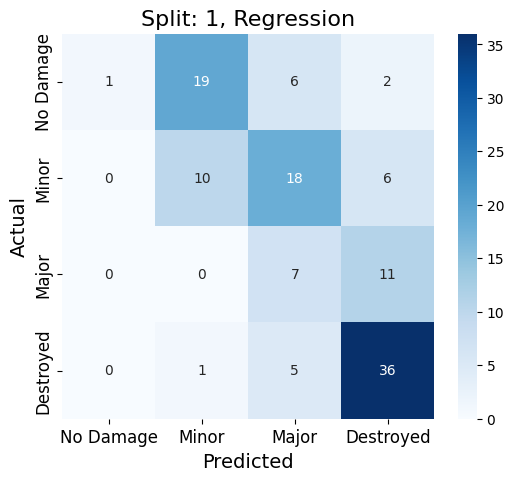


=== Fold 3 | Test folds: [4, 5] ===
['fold_4', 'fold_5']
['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_6', 'fold_7', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 4/4 [00:00<00:00,  5.22it/s]


Train Loss: 0.8932, Precision: 0.6004, Recall: 0.4398, F1: 0.4311, Accuracy: 0.4398
Val Loss: 0.7999, Precision: 0.6459, Recall: 0.4918, F1: 0.4928, Accuracy: 0.4918

Epoch 2/30


...

Train Loss: 0.1975, Precision: 0.8084, Recall: 0.7925, F1: 0.7975, Accuracy: 0.7925
Val Loss: 0.6145, Precision: 0.6679, Recall: 0.5984, F1: 0.5857, Accuracy: 0.5984

Epoch 30/30


Validation: 100%|██████████| 4/4 [00:00<00:00,  5.28it/s]


Train Loss: 0.2040, Precision: 0.8066, Recall: 0.7925, F1: 0.7971, Accuracy: 0.7925
Val Loss: 0.5615, Precision: 0.5604, Recall: 0.5656, F1: 0.5454, Accuracy: 0.5656
Evaluating...


Evaluating DamageNet: 100%|██████████| 4/4 [00:00<00:00,  5.26it/s]



DamageNet Evaluation (Regression):
  Loss:      0.5615
  Accuracy:  0.5656
  Precision: 0.5604
  Recall:    0.5656
  F1 Score:  0.5454
  MSE:       0.5456
  MAE:       0.5415


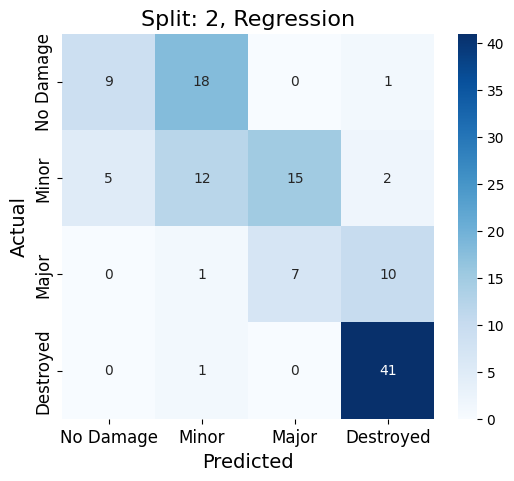


=== Fold 4 | Test folds: [6, 7] ===
['fold_6', 'fold_7']
['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_8', 'fold_9']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 4/4 [00:00<00:00,  5.33it/s]


Train Loss: 0.7640, Precision: 0.5980, Recall: 0.4153, F1: 0.4071, Accuracy: 0.4153
Val Loss: 0.8596, Precision: 0.5736, Recall: 0.4750, F1: 0.4728, Accuracy: 0.4750

Epoch 2/30


...

Train Loss: 0.1548, Precision: 0.8270, Recall: 0.8202, F1: 0.8227, Accuracy: 0.8202
Val Loss: 0.7322, Precision: 0.5267, Recall: 0.5000, F1: 0.4831, Accuracy: 0.5000

Epoch 30/30


Validation: 100%|██████████| 4/4 [00:00<00:00,  5.49it/s]


Train Loss: 0.1353, Precision: 0.8337, Recall: 0.8264, F1: 0.8285, Accuracy: 0.8264
Val Loss: 0.7570, Precision: 0.5152, Recall: 0.5000, F1: 0.4842, Accuracy: 0.5000
Evaluating...


Evaluating DamageNet: 100%|██████████| 4/4 [00:00<00:00,  5.55it/s]



DamageNet Evaluation (Regression):
  Loss:      0.7570
  Accuracy:  0.5000
  Precision: 0.5152
  Recall:    0.5000
  F1 Score:  0.4842
  MSE:       0.7572
  MAE:       0.6642


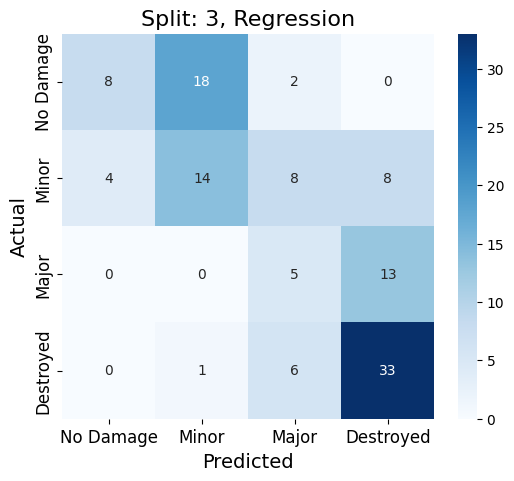


=== Fold 5 | Test folds: [8, 9] ===
['fold_8', 'fold_9']
['fold_0', 'fold_1', 'fold_2', 'fold_3', 'fold_4', 'fold_5', 'fold_6', 'fold_7']


/usr/local/lib/python3.11/dist-packages/torch/optim/lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Training...

Epoch 1/30


Validation: 100%|██████████| 4/4 [00:00<00:00,  5.12it/s]


Train Loss: 0.8420, Precision: 0.5896, Recall: 0.4239, F1: 0.4118, Accuracy: 0.4239
Val Loss: 0.7598, Precision: 0.6383, Recall: 0.5339, F1: 0.5391, Accuracy: 0.5339

Epoch 2/30


...

Train Loss: 0.2155, Precision: 0.8119, Recall: 0.8045, F1: 0.8071, Accuracy: 0.8045
Val Loss: 0.6766, Precision: 0.6306, Recall: 0.5763, F1: 0.5715, Accuracy: 0.5763

Epoch 30/30


Validation: 100%|██████████| 4/4 [00:01<00:00,  2.96it/s]


Train Loss: 0.1656, Precision: 0.8123, Recall: 0.7984, F1: 0.8031, Accuracy: 0.7984
Val Loss: 0.6090, Precision: 0.6275, Recall: 0.5678, F1: 0.5660, Accuracy: 0.5678
Evaluating...


Evaluating DamageNet: 100%|██████████| 4/4 [00:01<00:00,  3.84it/s]



DamageNet Evaluation (Regression):
  Loss:      0.6090
  Accuracy:  0.5678
  Precision: 0.6275
  Recall:    0.5678
  F1 Score:  0.5660
  MSE:       0.5772
  MAE:       0.5669


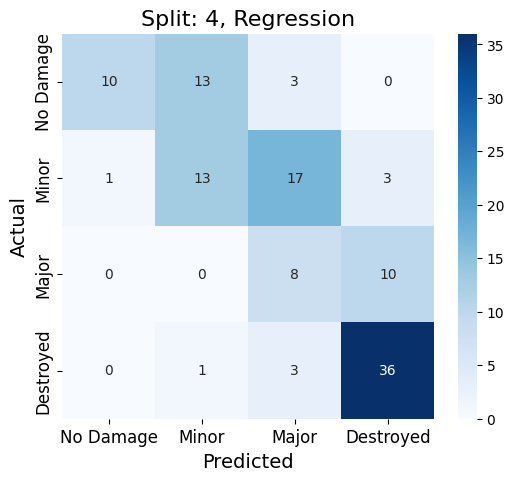


=== All Fold Test Metrics ===
       loss  accuracy  precision    recall  f1_score       mse       mae  \
0  0.863312  0.467213   0.549950  0.467213  0.454356  0.839085  0.682511   
1  1.032418  0.442623   0.576428  0.442623  0.396705  0.984002  0.769218   
2  0.561465  0.565574   0.560378  0.565574  0.545399  0.545608  0.541530   
3  0.757048  0.500000   0.515176  0.500000  0.484245  0.757171  0.664231   
4  0.609022  0.567797   0.627455  0.567797  0.565957  0.577247  0.566937   

   fold test_folds  
0     0     [0, 1]  
1     1     [2, 3]  
2     2     [4, 5]  
3     3     [6, 7]  
4     4     [8, 9]  


In [ ]:
popasna_df_reg = run_kfold_damagenet_experiments(
    DATA_DIR="/content/popasna_data/",
    transform=get_default_transforms(),
    checkpoint_path="/content/drive/MyDrive/thesis_code/classification/models/model_DamageNet_regression_15.pt",
    test_fold_combinations=[[0, 1], [2, 3], [4, 5], [6, 7], [8, 9]],
    epochs=30,
    mode="regression"
)

In [ ]:
output_path = '/content/drive/MyDrive/thesis_code/classification/results/df_popasna_reg.csv'
popasna_df_reg.to_csv(output_path, index=False)
print(f"\nSaved results to: {output_path}")


Saved results to: /content/drive/MyDrive/thesis_code/classification/results/df_popasna_reg.csv
